# Figures only — Manuscript v41

Rebuilds Figures 3–14 without re-running the linear-programming analysis.
The numerical inputs come from `manuscript_outputs (5).zip`, produced by
`Bangladesh_adequacy_framework_v41_ran (3).ipynb`.

The figure design is retained from `Figures_only_v37_colab3_ran`: the same
sans-serif font preference, bold axis text and tick values, colors, panel
layouts, legends, 600 dpi LZW TIFF export, PDF export, RGB conversion, and
final print widths.

Most panels read the archived tables directly. Figures 4–6 and the hourly
scatter in Figure 11 need observations that the archive does not store.
Those quantities are rebuilt in closed form from the same
`generation_data.csv`; a provenance check stops the notebook if that CSV
does not match the annual table in the supplied archive.

**How to run in Colab**

1. Put `manuscript_outputs (5).zip` in `MyDrive/Colab Notebooks`, or choose
   it when the setup cell opens an upload dialog.
2. Optionally put the matching `generation_data.csv` in the same Drive
   folder. If it is absent, the exact GitHub input used by the main notebook
   is downloaded automatically.
3. Run all cells. Each figure remains in its own cell, so it can then be
   edited and re-run independently.

| Manuscript | Content | Output file |
|---|---|---|
| Figure 3 | Annual demand, mix and shedding | `Figure03_system_evolution` |
| Figure 4 | Capacity-assumption robustness | `Figure04_capacity_robustness` |
| Figure 5 | Monthly shedding and changepoint | `Figure05_monthly_shedding` |
| Figure 6 | Idle capacity during shedding | `Figure06_idle_capacity` |
| Figure 7 | Regime-shift effect sizes | `Figure07_effect_sizes` |
| Figure 8 | Seasonality by calendar month | `Figure08_seasonality` |
| Figure 9 | Observed against simulated | `Figure09_reconstruction` |
| Figure 10 | Three model configurations | `Figure10_ablation` |
| Figure 11 | Out-of-sample prediction | `Figure11_out_of_sample` |
| Figure 12 | Global sensitivity analysis | `Figure12_gsa` |
| Figure 13 | Intervention effectiveness | `Figure13_effectiveness` |
| Figure 14 | Capacity sweep | `Figure14_capacity_sweep` |


## 0. Setup

In [1]:
!pip -q install ruptures==1.1.10
!apt-get -qq install -y fonts-liberation > /dev/null 2>&1

import os, warnings, numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import matplotlib, matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from PIL import Image
Image.MAX_IMAGE_PIXELS = None
print("matplotlib", matplotlib.__version__, "| pandas", pd.__version__)

matplotlib 3.10.0 | pandas 2.2.3


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import glob, shutil, zipfile
from urllib.request import urlretrieve
from google.colab import files

# ------------------------------------------------------------------
# Inputs. Edit either Drive path here if your files live elsewhere.
# ------------------------------------------------------------------
OUTPUTS_ZIP = "/content/drive/MyDrive/Colab Notebooks/PyPSA/manuscript_outputs (5).zip"
DRIVE_CSV   = "/content/drive/MyDrive/Colab Notebooks/PyPSA/generation_data.csv"

CSV_URL = (
    "https://raw.githubusercontent.com/"
    "MynulVG/Bangladesh-availability-constrained-adequacy-framework/"
    "main/generation_data.csv"
)

if not os.path.exists(OUTPUTS_ZIP):
    print("Choose the manuscript_outputs ZIP produced by the v41 notebook.")
    _uploaded = files.upload()
    _zip_names = [name for name in _uploaded if name.lower().endswith(".zip")]
    assert len(_zip_names) == 1, (
        "Upload exactly one ZIP file, or set OUTPUTS_ZIP to its Drive path."
    )
    OUTPUTS_ZIP = os.path.abspath(_zip_names[0])

if os.path.exists(DRIVE_CSV):
    CSV_PATH = DRIVE_CSV
    _csv_source = "Google Drive"
else:
    CSV_PATH = "/content/generation_data.csv"
    print("generation_data.csv not found in Drive; downloading the main-notebook input...")
    urlretrieve(CSV_URL, CSV_PATH)
    _csv_source = "project GitHub repository"

assert os.path.getsize(OUTPUTS_ZIP) > 1000, "The outputs ZIP is empty or invalid."
assert os.path.getsize(CSV_PATH) > 1000, "generation_data.csv is empty or invalid."

EXTRACT_ROOT = "/content/manuscript_outputs_v41"
if os.path.isdir(EXTRACT_ROOT):
    shutil.rmtree(EXTRACT_ROOT)
os.makedirs(EXTRACT_ROOT, exist_ok=True)

with zipfile.ZipFile(OUTPUTS_ZIP) as _archive:
    _root = os.path.realpath(EXTRACT_ROOT) + os.sep
    for _member in _archive.infolist():
        _destination = os.path.realpath(os.path.join(EXTRACT_ROOT, _member.filename))
        assert _destination == _root[:-1] or _destination.startswith(_root), (
            f"Unsafe path in ZIP: {_member.filename}"
        )
    _archive.extractall(EXTRACT_ROOT)

_table_dirs = sorted(glob.glob(f"{EXTRACT_ROOT}/**/tables", recursive=True))
assert _table_dirs, "No tables/ directory was found in the outputs ZIP."
TABLE_DIR = _table_dirs[0]
MORRIS_CSV = os.path.join(TABLE_DIR, "TS_morris.csv")

OUT_FIG = "/content/figures_v41"
os.makedirs(OUT_FIG, exist_ok=True)

print("outputs archive:", os.path.basename(OUTPUTS_ZIP))
print("tables found   :", len(glob.glob(f"{TABLE_DIR}/*.csv")))
print("hourly data    :", _csv_source)
print("figure folder  :", OUT_FIG)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
outputs archive: manuscript_outputs (5).zip
tables found   : 50
hourly data    : Google Drive
figure folder  : /content/figures_v41


## 1. Figure style

Identical to the style used for the submitted figures. Output is 600 dpi
LZW TIFF in RGB with no alpha channel, at final print width.

Change `plt.rcParams` here to restyle every figure at once.

In [3]:
import matplotlib.font_manager as fm

W_SINGLE, W_DOUBLE = 3.54, 7.48

# Refresh Matplotlib's font list, then prefer Arial.
fm.fontManager = fm._load_fontmanager(try_read_cache=False)
_available_fonts = {font.name for font in fm.fontManager.ttflist}

FONT = (
    "Arial" if "Arial" in _available_fonts
    else "Liberation Sans" if "Liberation Sans" in _available_fonts
    else "DejaVu Sans"
)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": [FONT],
    "font.size": 8,

    # Axis-label styling
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "axes.labelweight": "bold",

    # Tick-value sizing
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,

    "legend.fontsize": 7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
})

Cpal = {
    "normal": "#2166AC",
    "crisis": "#B2182B",
    "accent": "#F4A261",
    "grey": "#ADB5BD",
    "gas": "#4C72B0",
    "coal": "#55524E",
    "liquid": "#C44E52",
    "imp": "#8172B3",
    "ren": "#55A868",
}

def bold_axis_text(fig):
    """Make axis labels and tick values bold on every subplot."""
    for ax in fig.axes:
        ax.xaxis.label.set_fontweight("bold")
        ax.yaxis.label.set_fontweight("bold")

        plt.setp(ax.get_xticklabels(), fontweight="bold")
        plt.setp(ax.get_yticklabels(), fontweight="bold")

        # Also handles offset text such as ×10³.
        ax.xaxis.get_offset_text().set_fontweight("bold")
        ax.yaxis.get_offset_text().set_fontweight("bold")

def savefig(fig, name, width=W_DOUBLE):
    # Apply consistently to every figure before display/export.
    bold_axis_text(fig)

    w0, h0 = fig.get_size_inches()
    if w0 > 0:
        fig.set_size_inches(width, h0 * width / w0)

    tif = f"{OUT_FIG}/{name}.tiff"

    def _w():
        fig.savefig(
            tif,
            format="tiff",
            dpi=600,
            facecolor="white",
            pil_kwargs={"compression": "tiff_lzw"},
        )
        fig.savefig(
            f"{OUT_FIG}/{name}.pdf",
            facecolor="white",
        )

    try:
        fig.set_layout_engine("constrained")
        _w()
    except Exception:
        fig.set_layout_engine("none")
        fig.tight_layout()
        _w()

    im = Image.open(tif)

    if im.mode != "RGB":
        rgb = Image.new("RGB", im.size, (255, 255, 255))
        rgb.paste(
            im,
            mask=im.split()[-1] if im.mode in ("RGBA", "LA") else None,
        )
        rgb.save(
            tif,
            format="TIFF",
            compression="tiff_lzw",
            dpi=(600, 600),
        )
        im = Image.open(tif)

    w, h = im.size
    print(
        f"  {name}: {w}x{h}px = "
        f"{w / 600:.2f}x{h / 600:.2f}in  {im.mode}"
    )
    return tif

print("style ready | font:", FONT)
print("axis labels and tick values: bold")

style ready | font: Liberation Sans
axis labels and tick values: bold


## 2. Data and derived quantities

Archived manuscript values are loaded from the supplied ZIP. Only the
unexported hourly point clouds are reconstructed from the matching source
record; no optimizer or PyPSA network is used.


In [4]:
from collections import Counter

# Installed capacities used by the v41 analysis and its clean network.
CAP = {
    "Gas": 6644.0,
    "Coal": 4143.635120,
    "Liquid Fuel": 3995.130,
    "Import": 1093.0,
    "Hydro": 211.0,
    "Solar": 390.752128,
    "Wind": 29.033770,
}
TECHS = list(CAP)
THERMAL = ["Gas", "Coal", "Liquid Fuel"]
DISPATCHABLE = ["Gas", "Coal", "Liquid Fuel", "Import", "Hydro"]
PERIODS = ["2016-12", "2022-08", "2023-06", "2023-08"]
SEED, BOOT = 42, 2000

def load_data(path=CSV_PATH):
    """Load the hourly record and apply the two repairs used in v41."""
    d = pd.read_csv(path)
    d["datetime"] = pd.to_datetime(
        d["Date"].astype(str) + " " + d["Time"].astype(str),
        format="%d.%m.%Y %H:%M:%S",
    )
    d = d.sort_values("datetime").reset_index(drop=True)

    for column in ["Bheramara HVDC", "Tripura", "Adani"]:
        d[column] = pd.to_numeric(d[column], errors="coerce").fillna(0.0)
    d["Import"] = d[["Bheramara HVDC", "Tripura", "Adani"]].sum(axis=1)

    for column in ["Demand", "Generation", "Loadshed"] + TECHS:
        d[column] = pd.to_numeric(d[column], errors="coerce")

    i = d.index[d["datetime"] == pd.Timestamp("2021-08-16 01:00")][0]
    for column in ["Demand", "Generation"] + TECHS:
        d.loc[i, column] = round(0.5 * (d.loc[i - 1, column] + d.loc[i + 1, column]), 1)

    j = d.index[d["datetime"] == pd.Timestamp("2015-06-08 14:00")][0]
    for column in ["Demand", "Generation", "Gas"]:
        d.loc[j, column] = round(0.5 * (d.loc[j - 1, column] + d.loc[j + 1, column]), 1)
    return d

def slice_month(ym, frame=None):
    f = df if frame is None else frame
    year, month = int(ym[:4]), int(ym[5:7])
    start = pd.Timestamp(year, month, 1)
    end = pd.Timestamp(year + (month == 12), (month % 12) + 1, 1)
    return f[(f["datetime"] >= start) & (f["datetime"] < end)].set_index("datetime")

def available(frame):
    return sum(np.minimum(frame[t].fillna(0.0), CAP[t]) for t in TECHS)

def anomaly_flags(d, thresh=0.5, min_series=3, floor=200.0):
    counts = Counter()
    for column in ["Demand", "Generation"] + TECHS:
        s = d[column]
        neighbour_mean = (s.shift(1) + s.shift(-1)) / 2
        flagged = (
            ((s - s.shift(1)).abs() > thresh * neighbour_mean)
            & ((s - s.shift(-1)).abs() > thresh * neighbour_mean)
            & (neighbour_mean > floor)
            & ((s - neighbour_mean).abs() > thresh * neighbour_mean)
        )
        for index in d.index[flagged.fillna(False)]:
            counts[index] += 1
    return sorted(index for index, count in counts.items() if count >= min_series)

df = load_data()
print(f"{len(df):,} rows  {df['datetime'].min()} -> {df['datetime'].max()}")


84,186 rows  2015-04-20 00:00:00 -> 2024-11-25 17:00:00


In [5]:
def read_output_table(name):
    path = os.path.join(TABLE_DIR, name)
    assert os.path.exists(path), f"Required output table is missing: {name}"
    return pd.read_csv(path)

# ------------------------------------------------------------------
# Direct manuscript-output inputs.
# ------------------------------------------------------------------
annual2 = read_output_table("TS_annual_context.csv")
regime_tests = read_output_table("TS_regime_tests.csv")
seas = read_output_table("TS_seasonality.csv")
val_df = read_output_table("T2_reconstruction_fidelity.csv")
abl_df = read_output_table("T3_ablation.csv")
oos_all = read_output_table("T4_out_of_sample.csv")
interv = read_output_table("T6_interventions_all_months.csv")
sweep_df = read_output_table("TS_capacity_sweep.csv")
battery_all = read_output_table("TS_battery_all_months.csv")
changepoint = read_output_table("TS_changepoint_robustness.csv").iloc[0]

annual2["Year"] = annual2["Year"].astype(int)
_month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
seas = seas.set_index("month").loc[_month_order].reset_index()

# Figure 10 keeps the manuscript-facing labels used by the styled v37 cell.
_config_labels = {"IC": "Model 1", "no_LF": "Model 2", "full": "Model 3"}
abl_df["config"] = abl_df["config"].replace(_config_labels)

# Figure 11's right panel is explicitly the rolling-origin comparison.
oos_null = oos_all[oos_all["protocol"] == "rolling-origin"].copy()
NAMES = {
    "A": "per-technology hour-of-day [as specified]",
    "B": "constant capacity (null)",
    "C": "demand only (null)",
    "D": "aggregate hour-of-day (null)",
}

# Figure 13 uses the availability-inheriting intervention columns.
for technology in DISPATCHABLE:
    interv[technology] = interv[f"{technology}_inherits"]
hi = interv[interv["base"] > 100].copy()
N_HI = len(hi)
BATT_MAX_EFF = float(battery_all["effectiveness"].max())

CP_POINT = str(changepoint["point_estimate"])
CP_LO = str(changepoint["ci95_low"])
CP_HI = str(changepoint["ci95_high"])

warm = seas[seas["month"].isin(["Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct"])]
cool = seas[seas["month"].isin(["Nov", "Dec", "Jan", "Feb", "Mar"])]
DEM_RATIO = warm["mean_demand_mw"].mean() / cool["mean_demand_mw"].mean()
SHED_RATIO = warm["mean_shed_mw"].mean() / cool["mean_shed_mw"].mean()

# ------------------------------------------------------------------
# Unexported hourly inputs for Figures 4–6 and Figure 11(a).
# ------------------------------------------------------------------
crisis_all = df[df["datetime"].dt.year.between(2022, 2024)]
shed = crisis_all[crisis_all["Loadshed"] > 0].copy()
CAPS = {technology: CAP[technology] for technology in THERMAL}
shed["idle_thermal"] = sum(
    (CAPS[t] - shed[t].fillna(0.0)).clip(lower=0) for t in THERMAL
)
worst = shed[shed["Loadshed"] >= shed["Loadshed"].quantile(0.90)].copy()

_flags = anomaly_flags(df)
_clean_df = df.drop(index=_flags)
_assumed_thermal = sum(CAPS.values())
IMPLIED_LAMBDA = _clean_df[THERMAL].sum(axis=1).max() / _assumed_thermal

mo_shed = df.groupby(df["datetime"].dt.to_period("M"))["Loadshed"].mean()

def _hour_of_day_availability(training):
    total = np.zeros(24)
    for technology in TECHS:
        cf = (training[technology].fillna(0.0) / CAP[technology]).clip(0, 1)
        total += (
            cf.groupby(training.index.hour)
            .mean()
            .reindex(range(24))
            .values
            * CAP[technology]
        )
    return total

OOS_CAPTURE = {}
for name, ym in [("Jun2023", "2023-06"), ("Aug2023", "2023-08")]:
    month = slice_month(ym)
    n = len(month)
    boundaries = [round(i * n / 5) for i in range(6)]
    predicted, observed = [], []
    for fold in range(5):
        test = month.iloc[boundaries[fold]:boundaries[fold + 1]]
        training = pd.concat([
            month.iloc[:boundaries[fold]],
            month.iloc[boundaries[fold + 1]:],
        ])
        if len(test) < 24 or test["Loadshed"].std() == 0:
            continue
        hours = test.index.hour.values
        model = np.clip(
            test["Demand"].values - _hour_of_day_availability(training)[hours],
            0,
            None,
        )
        predicted.extend(model)
        observed.extend(test["Loadshed"].values)

    predicted = np.asarray(predicted)
    observed = np.asarray(observed)
    pooled_r = float(np.corrcoef(predicted, observed)[0, 1])
    OOS_CAPTURE[name] = {
        "model": predicted,
        "obs": observed,
        "pooled_r": pooled_r,
    }

    _reported_r = float(
        oos_null[
            (oos_null["month"] == ym)
            & (oos_null["spec"] == NAMES["A"])
        ]["r"].iloc[0]
    )
    assert abs(round(pooled_r, 3) - _reported_r) <= 0.001, (
        f"{ym} hourly data do not reproduce the ZIP's out-of-sample result "
        f"({pooled_r:.3f} vs {_reported_r:.3f}). Use the generation_data.csv "
        "that produced this outputs archive."
    )

# Provenance guard: the hourly CSV must reproduce the archived annual data.
_annual_check = df.assign(Year=df["datetime"].dt.year).groupby("Year").agg(
    Demand_mean=("Demand", "mean"),
    Loadshed_GWh=("Loadshed", lambda values: values.sum() / 1000),
    hours=("Demand", "size"),
).reset_index()
_joined = annual2[["Year", "Demand_mean", "Loadshed_GWh", "hours"]].merge(
    _annual_check,
    on="Year",
    suffixes=("_archive", "_raw"),
    validate="one_to_one",
)
assert np.allclose(
    _joined["Demand_mean_archive"], _joined["Demand_mean_raw"],
    rtol=1e-10, atol=1e-6,
) and np.allclose(
    _joined["Loadshed_GWh_archive"], _joined["Loadshed_GWh_raw"],
    rtol=1e-10, atol=1e-6,
) and (_joined["hours_archive"] == _joined["hours_raw"]).all(), (
    "generation_data.csv does not match the supplied manuscript_outputs ZIP."
)

print("updated figure inputs ready")
print(f"  archive tables       : 10 required tables loaded")
print(f"  changepoint          : {CP_POINT} (95% CI {CP_LO} to {CP_HI})")
print(f"  high-stress months   : {N_HI}")
print(f"  battery bound        : {BATT_MAX_EFF:.4f} MW/MW")
print(f"  hourly provenance    : matched archive")


updated figure inputs ready
  archive tables       : 10 required tables loaded
  changepoint          : 2022-04 (95% CI 2022-04 to 2023-02)
  high-stress months   : 26
  battery bound        : 0.0296 MW/MW
  hourly provenance    : matched archive


## 3. Figures

One cell per figure. Edit and re-run a single cell to see the change.

### Figure 3 — annual demand, generation mix and load shedding

  Figure03_system_evolution: 4488x4800px = 7.48x8.00in  RGB


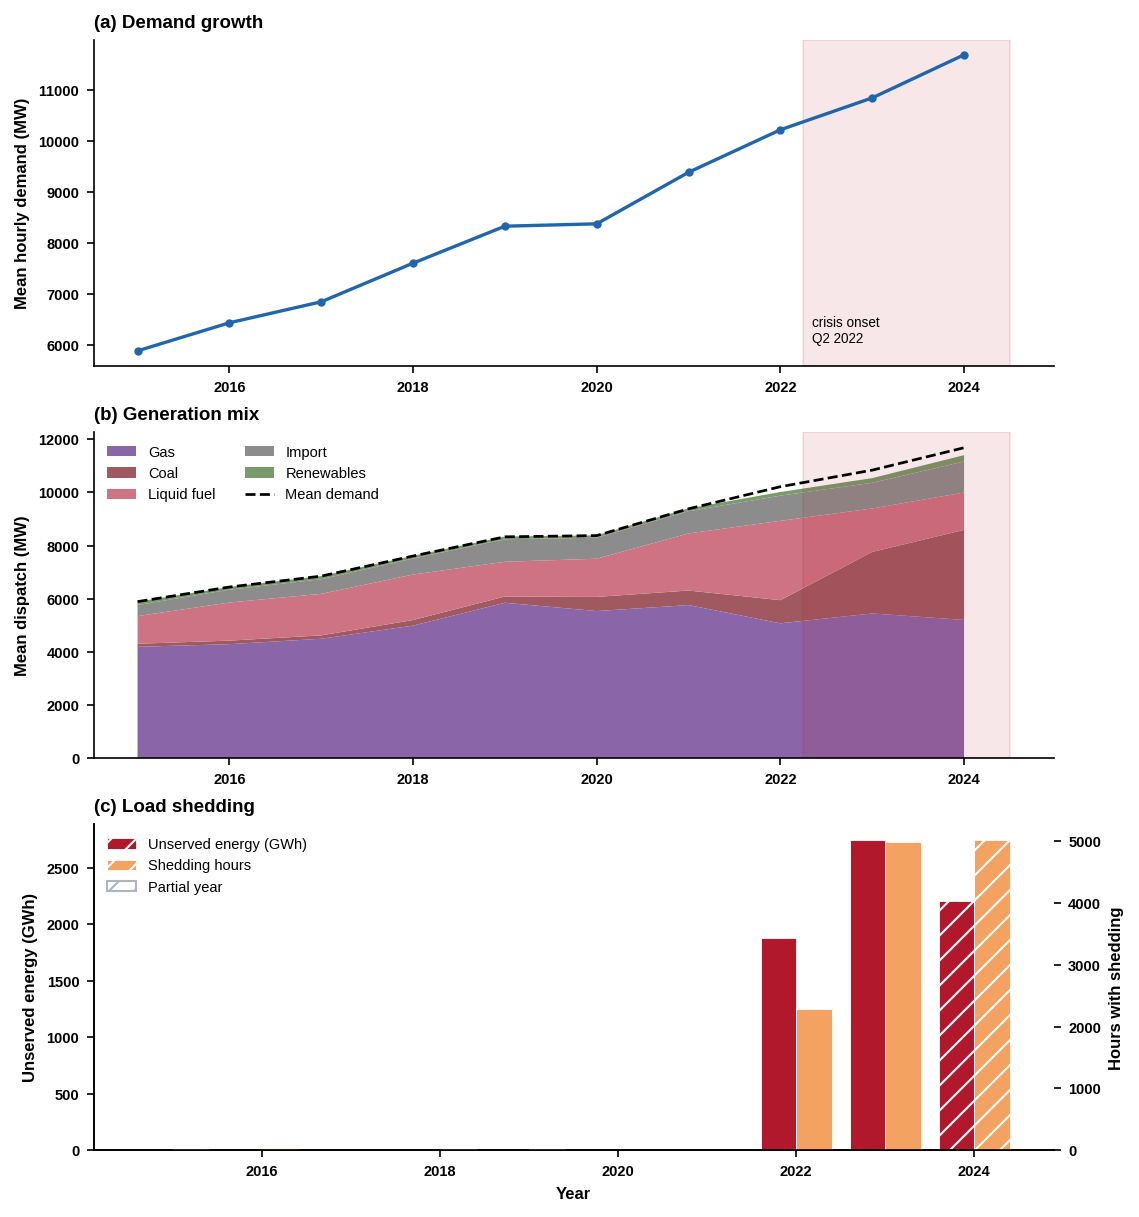

In [6]:
years = annual2["Year"].values
partial = (annual2["hours"] < 8000).values

CRISIS_X = 2022 + 3 / 12

# Our World in Data source colors sampled from the supplied charts.
OWID_SOURCE_COLORS = {
    "Gas": "#8A65A7",
    "Coal": "#A05961",
    "Liquid fuel": "#CD7384",   # OWID Oil
    "Import": "#8C8C8C",       # Neutral: import is not a fuel source
    "Renewables": "#799A6A",   # OWID Other renewables
}

fig, axes = plt.subplots(3, 1, figsize=(7.48, 8.0))

# ------------------------------------------------------------------
# (a) Demand growth
# ------------------------------------------------------------------
ax = axes[0]

ax.plot(
    years,
    annual2["Demand_mean"],
    "-o",
    color=Cpal["normal"],
    lw=1.6,
    ms=3,
)

ax.axvspan(
    CRISIS_X,
    years.max() + 0.5,
    color=Cpal["crisis"],
    alpha=0.10,
)

ax.annotate(
    "crisis onset\nQ2 2022",
    xy=(CRISIS_X, annual2["Demand_mean"].min()),
    xytext=(4, 4),
    textcoords="offset points",
    fontsize=6.5,
)

ax.set_ylabel("Mean hourly demand (MW)")
ax.set_title(
    "(a) Demand growth",
    loc="left",
    fontweight="bold",
)

# ------------------------------------------------------------------
# (b) Generation mix
# ------------------------------------------------------------------
ax = axes[1]

stack = [
    "Gas_mean",
    "Coal_mean",
    "Liquid_mean",
    "Import_mean",
    "Renewable_mean",
]

stack_labels = [
    "Gas",
    "Coal",
    "Liquid fuel",
    "Import",
    "Renewables",
]

ax.stackplot(
    years,
    [annual2[source] for source in stack],
    labels=stack_labels,
    colors=[OWID_SOURCE_COLORS[label] for label in stack_labels],
    alpha=1.0,
    edgecolor="none",
)

ax.plot(
    years,
    annual2["Demand_mean"],
    "k--",
    lw=1.3,
    label="Mean demand",
)

ax.axvspan(
    CRISIS_X,
    years.max() + 0.5,
    color=Cpal["crisis"],
    alpha=0.10,
)

ax.legend(
    loc="upper left",
    ncol=2,
    frameon=False,
)

ax.set_ylabel("Mean dispatch (MW)")
ax.set_title(
    "(b) Generation mix",
    loc="left",
    fontweight="bold",
)

# ------------------------------------------------------------------
# (c) Load shedding
# ------------------------------------------------------------------
ax = axes[2]

b1 = ax.bar(
    years - 0.2,
    annual2["Loadshed_GWh"],
    0.4,
    color=Cpal["crisis"],
    hatch=["//" if p else "" for p in partial],
    edgecolor="white",
    linewidth=0.4,
    label="Unserved energy (GWh)",
)

ax2 = ax.twinx()
ax2.spines["top"].set_visible(False)

b2 = ax2.bar(
    years + 0.2,
    annual2["Loadshed_hrs"],
    0.4,
    color=Cpal["accent"],
    hatch=["//" if p else "" for p in partial],
    edgecolor="white",
    linewidth=0.4,
    label="Shedding hours",
)

ax.set_ylabel("Unserved energy (GWh)")
ax2.set_ylabel("Hours with shedding")
ax.set_xlabel("Year")

ax.set_title(
    "(c) Load shedding",
    loc="left",
    fontweight="bold",
)

ax.legend(
    handles=[
        b1,
        b2,
        mpatches.Patch(
            facecolor="white",
            edgecolor=Cpal["grey"],
            hatch="//",
            label="Partial year",
        ),
    ],
    loc="upper left",
    frameon=False,
)

savefig(fig, "Figure03_system_evolution")
plt.show()

### Figure 4 — sensitivity to the assumed thermal nameplate

  Figure04_capacity_robustness: 4488x1800px = 7.48x3.00in  RGB


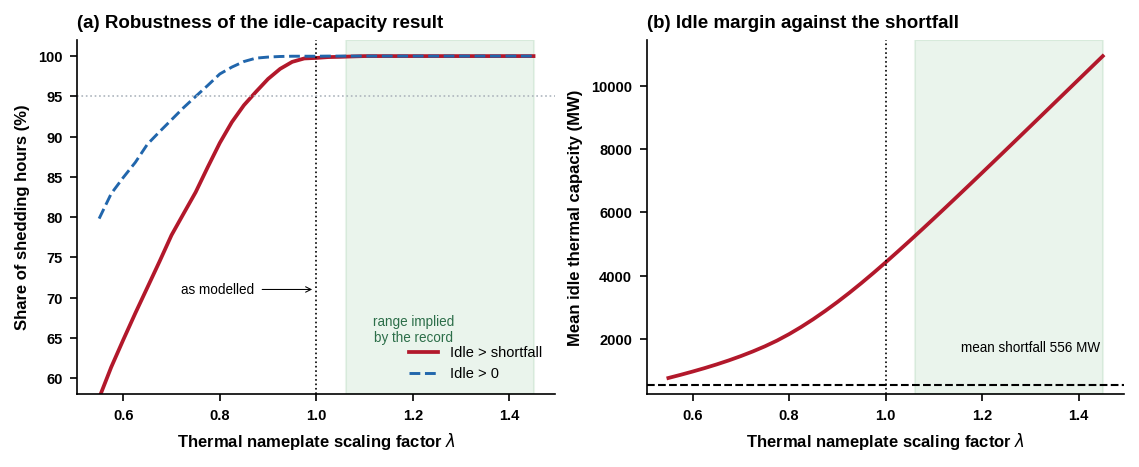

In [7]:
lams = np.arange(0.55,1.46,0.025)
gt_s, gt_0, idle_m = [], [], []
for lam in lams:
    idle = sum((CAPS[t]*lam-shed[t].fillna(0.0)).clip(lower=0) for t in THERMAL)
    gt_s.append(100*float((idle>shed["Loadshed"]).mean()))
    gt_0.append(100*float((idle>0).mean())); idle_m.append(float(idle.mean()))

fig, axes = plt.subplots(1,2, figsize=(7.48,3.0))
ax = axes[0]
ax.plot(lams, gt_s, color=Cpal["crisis"], lw=1.8, label="Idle > shortfall")
ax.plot(lams, gt_0, color=Cpal["normal"], lw=1.4, ls="--", label="Idle > 0")
ax.axvspan(IMPLIED_LAMBDA, lams.max(), color=Cpal["ren"], alpha=0.12)
ax.axvline(1.0, color="k", lw=0.8, ls=":"); ax.axhline(95, color=Cpal["grey"], lw=0.8, ls=":")
ax.annotate("as modelled", xy=(1.0,71), xytext=(-30,0), fontsize=6.5,
            textcoords="offset points", ha="right", va="center",
            arrowprops=dict(arrowstyle="->", lw=0.5, color="k"))
ax.annotate("range implied\nby the record", xy=(IMPLIED_LAMBDA+0.14,66), fontsize=6.5,
            color="#2C6E49", ha="center", va="center")
ax.set_xlabel("Thermal nameplate scaling factor $\\lambda$")
ax.set_ylabel("Share of shedding hours (%)"); ax.set_ylim(58,102)
ax.set_title("(a) Robustness of the idle-capacity result", loc="left", fontweight="bold")
ax.legend(frameon=False, loc="lower right")

ax = axes[1]
ax.plot(lams, idle_m, color=Cpal["crisis"], lw=1.8)
ax.axhline(shed["Loadshed"].mean(), color="k", ls="--", lw=1.0)
ax.annotate(f"mean shortfall {shed['Loadshed'].mean():.0f} MW",
            xy=(1.30, shed["Loadshed"].mean()), xytext=(0,16),
            textcoords="offset points", fontsize=6.5, ha="center")
ax.axvspan(IMPLIED_LAMBDA, lams.max(), color=Cpal["ren"], alpha=0.12)
ax.axvline(1.0, color="k", lw=0.8, ls=":")
ax.set_xlabel("Thermal nameplate scaling factor $\\lambda$")
ax.set_ylabel("Mean idle thermal capacity (MW)")
ax.set_title("(b) Idle margin against the shortfall", loc="left", fontweight="bold")
savefig(fig, "Figure04_capacity_robustness"); plt.show()

### Figure 5 — monthly shedding and the changepoint

  Figure05_monthly_shedding: 4488x1800px = 7.48x3.00in  RGB


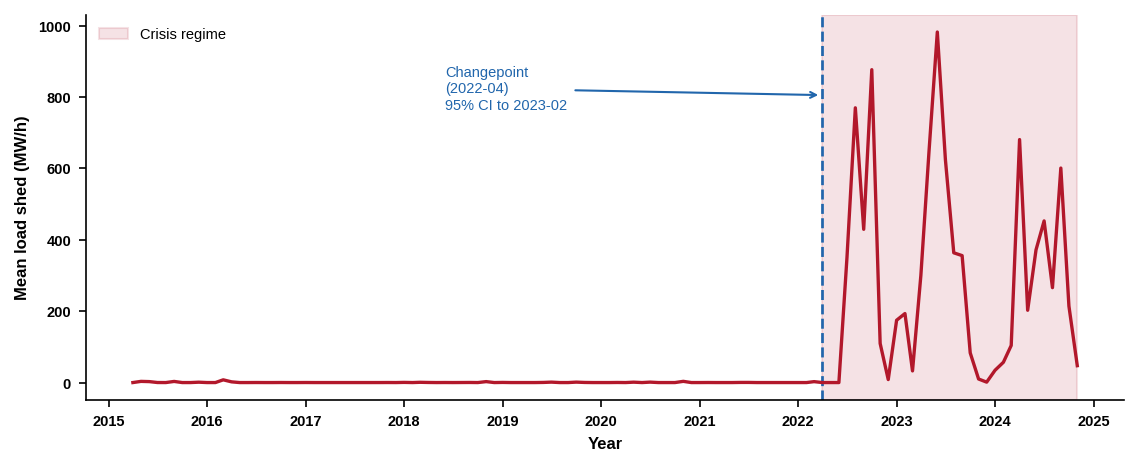

In [8]:
mon3 = mo_shed.reset_index()
mon3.columns = ["ym", "shed"]

mon3["t"] = mon3["ym"].dt.to_timestamp()

cpx = pd.Timestamp(CP_POINT + "-01")

fig, ax = plt.subplots(figsize=(7.48, 3.0))

ax.axvspan(
    cpx,
    mon3["t"].max(),
    color=Cpal["crisis"],
    alpha=0.12,
    zorder=0,
    label="Crisis regime",
)

ax.plot(
    mon3["t"],
    mon3["shed"],
    color=Cpal["crisis"],
    lw=1.6,
    zorder=3,
)

ax.axvline(
    cpx,
    color=Cpal["normal"],
    ls="--",
    lw=1.3,
    zorder=2,
)

ax.annotate(
    f"Changepoint\n({CP_POINT})\n95% CI to {CP_HI}",
    xy=(cpx, mon3["shed"].max() * 0.82),
    xytext=(
        pd.Timestamp("2018-06-01"),
        mon3["shed"].max() * 0.78,
    ),
    arrowprops=dict(
        arrowstyle="->",
        color=Cpal["normal"],
    ),
    color=Cpal["normal"],
    fontsize=7,
)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.set_xlabel("Year")
ax.set_ylabel("Mean load shed (MW/h)")

ax.legend(
    loc="upper left",
    frameon=False,
)

savefig(fig, "Figure05_monthly_shedding")
plt.show()

### Figure 6 — idle thermal capacity during shedding hours

  Figure06_idle_capacity: 4488x1860px = 7.48x3.10in  RGB


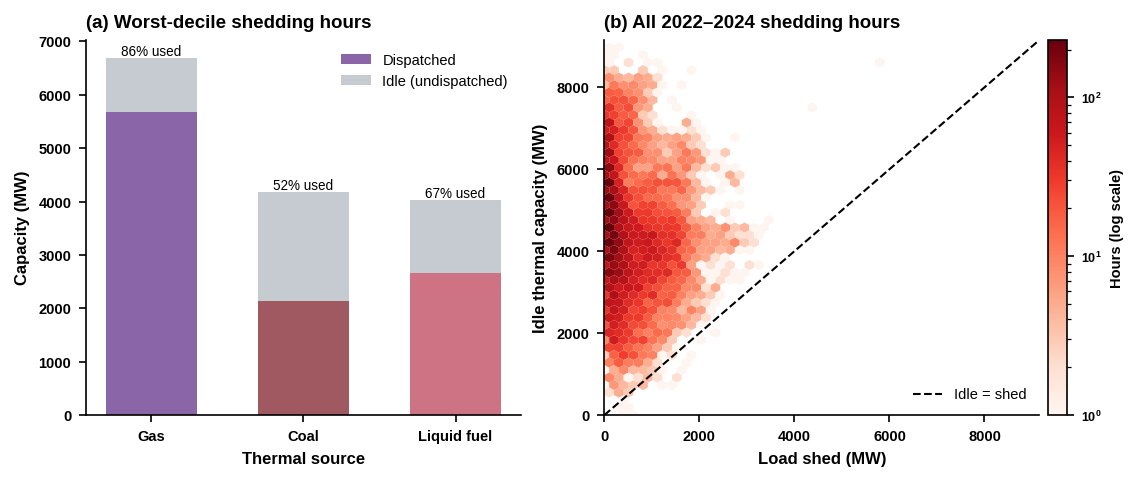

In [9]:
# Our World in Data source colors used in Figure 3.
OWID_THERMAL_COLORS = {
    "Gas": "#8A65A7",
    "Coal": "#A05961",
    "Liquid fuel": "#CD7384",  # OWID Oil
}

fig, axes = plt.subplots(
    1,
    2,
    figsize=(7.48, 3.1),
    layout="constrained",
)

# ------------------------------------------------------------------
# (a) Dispatched and idle thermal capacity
# ------------------------------------------------------------------
ax = axes[0]

disp = [worst[t].mean() for t in THERMAL]
idle = [
    (CAPS[t] - worst[t]).clip(lower=0).mean()
    for t in THERMAL
]

source_labels = ["Gas", "Coal", "Liquid fuel"]
x = np.arange(len(source_labels))

ax.bar(
    x,
    disp,
    0.6,
    color=[
        OWID_THERMAL_COLORS[source]
        for source in source_labels
    ],
    label="Dispatched",
)

ax.bar(
    x,
    idle,
    0.6,
    bottom=disp,
    color=Cpal["grey"],
    alpha=0.7,
    label="Idle (undispatched)",
)

for i, technology in enumerate(THERMAL):
    ax.text(
        i,
        CAPS[technology] + 90,
        f"{disp[i] / CAPS[technology] * 100:.0f}% used",
        ha="center",
        fontsize=6.5,
    )

ax.set_xticks(x)
ax.set_xticklabels(source_labels)

ax.set_xlabel("Thermal source")
ax.set_ylabel("Capacity (MW)")

ax.set_title(
    "(a) Worst-decile shedding hours",
    loc="left",
    fontweight="bold",
)

ax.legend(frameon=False)

# ------------------------------------------------------------------
# (b) Idle thermal capacity versus load shed
# ------------------------------------------------------------------
ax = axes[1]

xs = shed["Loadshed"].values
ys = shed["idle_thermal"].values

lim = max(
    np.percentile(xs, 99.9),
    np.percentile(ys, 99.9),
) * 1.05

hb = ax.hexbin(
    xs,
    ys,
    gridsize=45,
    cmap="Reds",
    bins="log",
    extent=(0, lim, 0, lim),
    mincnt=1,
    linewidths=0,
)

ax.plot(
    [0, lim],
    [0, lim],
    "k--",
    lw=1.0,
    label="Idle = shed",
)

ax.set_xlim(0, lim)
ax.set_ylim(0, lim)

cb = fig.colorbar(
    hb,
    ax=ax,
    pad=0.02,
)

cb.set_label(
    "Hours (log scale)",
    fontsize=7,
)

cb.ax.tick_params(labelsize=6)

ax.set_xlabel("Load shed (MW)")
ax.set_ylabel("Idle thermal capacity (MW)")

ax.set_title(
    "(b) All 2022–2024 shedding hours",
    loc="left",
    fontweight="bold",
)

ax.legend(
    frameon=False,
    loc="lower right",
)

savefig(fig, "Figure06_idle_capacity")
plt.show()

### Figure 7 — regime-shift effect sizes

  Figure07_effect_sizes: 4488x2160px = 7.48x3.60in  RGB


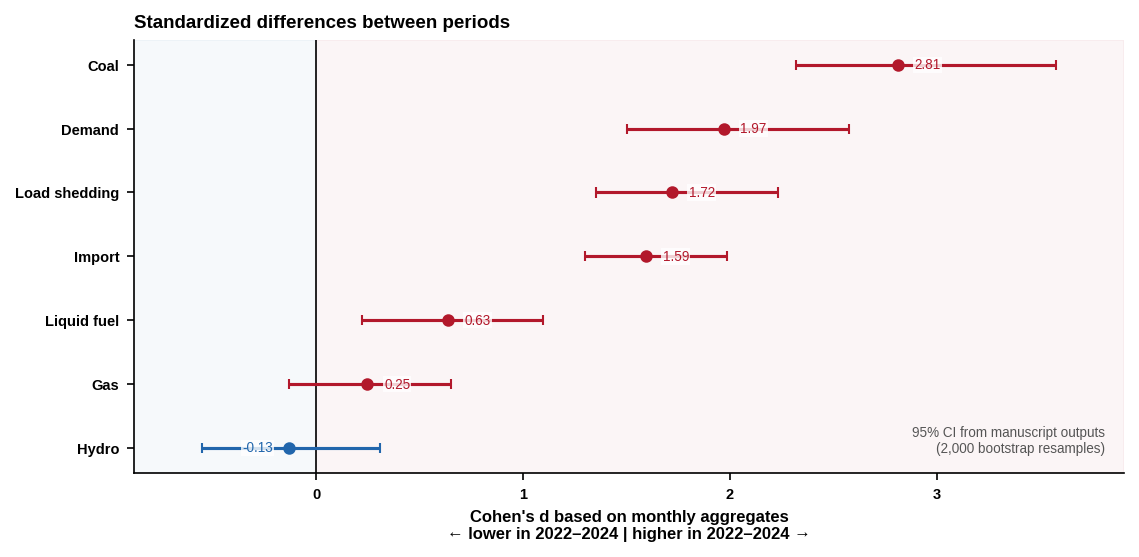

In [10]:
# The v41 archive is authoritative for the estimates and intervals.
_EFFECT_ROWS = [
    ("Demand", "Demand"),
    ("Gas", "Gas"),
    ("Coal", "Coal"),
    ("Liquid fuel", "Liquid_fuel"),
    ("Import", "Import"),
    ("Hydro", "Hydro"),
    ("Load shedding", "Load_shedding"),
]

effect_results = []
for label, variable in _EFFECT_ROWS:
    row = regime_tests[regime_tests["Variable"] == variable].iloc[0]
    effect_results.append({
        "Variable": label,
        "d": float(row["d_monthly"]),
        "CI_low": float(row["CI_lo"]),
        "CI_high": float(row["CI_hi"]),
    })

effect_results = (
    pd.DataFrame(effect_results)
    .sort_values("d")
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(7.48, 3.6))

minimum = min(0, effect_results["CI_low"].min())
maximum = max(0, effect_results["CI_high"].max())

data_span = max(maximum - minimum, 1.0)
x_left = minimum - 0.08 * data_span
x_right = maximum + 0.08 * data_span

ax.axvspan(
    x_left,
    0,
    color=Cpal["normal"],
    alpha=0.04,
    zorder=0,
)

ax.axvspan(
    0,
    x_right,
    color=Cpal["crisis"],
    alpha=0.04,
    zorder=0,
)

for i, row in effect_results.iterrows():
    color = (
        Cpal["crisis"]
        if row["d"] >= 0
        else Cpal["normal"]
    )

    ax.hlines(
        i,
        row["CI_low"],
        row["CI_high"],
        color=color,
        lw=1.5,
        zorder=2,
    )

    ax.vlines(
        [row["CI_low"], row["CI_high"]],
        i - 0.08,
        i + 0.08,
        color=color,
        lw=1.0,
        zorder=2,
    )

    ax.plot(
        row["d"],
        i,
        "o",
        color=color,
        ms=5,
        zorder=3,
    )

    # Place the estimate beside its dot, not beside the CI endpoint.
    text_offset = 8 if row["d"] >= 0 else -8
    horizontal_alignment = "left" if row["d"] >= 0 else "right"

    ax.annotate(
        f"{row['d']:.2f}",
        xy=(row["d"], i),
        xytext=(text_offset, 0),
        textcoords="offset points",
        ha=horizontal_alignment,
        va="center",
        fontsize=6.5,
        color=color,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.80,
            pad=0.6,
        ),
        zorder=4,
    )

ax.axvline(
    0,
    color="black",
    lw=0.8,
    zorder=1,
)

ax.set_xlim(x_left, x_right)

ax.set_yticks(np.arange(len(effect_results)))
ax.set_yticklabels(effect_results["Variable"])

ax.set_xlabel(
    "Cohen's d based on monthly aggregates\n"
    "← lower in 2022–2024 | higher in 2022–2024 →"
)

ax.set_title(
    "Standardized differences between periods",
    loc="left",
    fontweight="bold",
)

ax.text(
    0.98,
    0.04,
    f"95% CI from manuscript outputs\n"
    f"({BOOT:,} bootstrap resamples)",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=6.5,
    color="#555555",
)

savefig(fig, "Figure07_effect_sizes")
plt.show()

### Figure 8 — crisis-period statistics by calendar month

  Figure08_seasonality: 4488x2129px = 7.48x3.55in  RGB


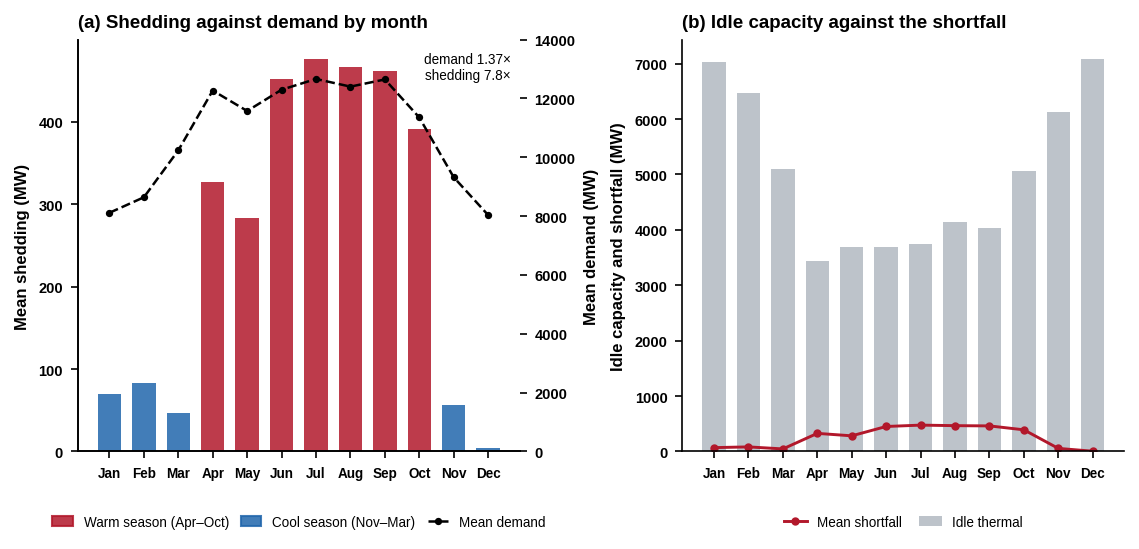

In [11]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(7.48, 3.55),
    layout="constrained",
)

x = np.arange(12)
warm_i = [3, 4, 5, 6, 7, 8, 9]

# ------------------------------------------------------------------
# (a) Monthly shedding and demand
# ------------------------------------------------------------------
ax = axes[0]

ax.bar(
    x,
    seas["mean_shed_mw"],
    0.68,
    color=[
        Cpal["crisis"] if i in warm_i else Cpal["normal"]
        for i in x
    ],
    alpha=0.85,
)

ax2 = ax.twinx()
ax2.spines["top"].set_visible(False)

ax2.plot(
    x,
    seas["mean_demand_mw"],
    "k--o",
    ms=2.5,
    lw=1.2,
)

ax.set_xticks(x)
ax.set_xticklabels(
    seas["month"],
    fontsize=6.5,
)

ax.set_ylabel("Mean shedding (MW)")
ax2.set_ylabel("Mean demand (MW)")
ax2.set_ylim(0, 14000)

ax.set_title(
    "(a) Shedding against demand by month",
    loc="left",
    fontweight="bold",
)

legend_a = [
    mpatches.Patch(
        color=Cpal["crisis"],
        alpha=0.85,
        label="Warm season (Apr–Oct)",
    ),
    mpatches.Patch(
        color=Cpal["normal"],
        alpha=0.85,
        label="Cool season (Nov–Mar)",
    ),
    plt.Line2D(
        [],
        [],
        color="black",
        ls="--",
        marker="o",
        ms=2.5,
        lw=1.2,
        label="Mean demand",
    ),
]

ax.legend(
    handles=legend_a,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.14),
    ncol=3,
    frameon=False,
    columnspacing=0.9,
    handlelength=1.5,
    borderaxespad=0,
    fontsize=6.5,
)

ax.text(
    0.98,
    0.97,
    f"demand {DEM_RATIO:.2f}×\n"
    f"shedding {SHED_RATIO:.1f}×",
    transform=ax.transAxes,
    va="top",
    ha="right",
    fontsize=6.5,
)

# ------------------------------------------------------------------
# (b) Idle capacity and shortfall
# ------------------------------------------------------------------
ax = axes[1]

idle_bars = ax.bar(
    x,
    seas["mean_idle_mw"],
    0.68,
    color=Cpal["grey"],
    alpha=0.8,
    label="Idle thermal",
)

shortfall_line, = ax.plot(
    x,
    seas["mean_shed_mw"],
    "-o",
    ms=3,
    lw=1.4,
    color=Cpal["crisis"],
    label="Mean shortfall",
)

ax.set_xticks(x)
ax.set_xticklabels(
    seas["month"],
    fontsize=6.5,
)

ax.set_ylabel("Idle capacity and shortfall (MW)")

ax.set_title(
    "(b) Idle capacity against the shortfall",
    loc="left",
    fontweight="bold",
)

ax.legend(
    handles=[shortfall_line, idle_bars],
    labels=["Mean shortfall", "Idle thermal"],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.14),
    ncol=2,
    frameon=False,
    columnspacing=1.2,
    handlelength=1.7,
    borderaxespad=0,
    fontsize=6.5,
)

savefig(fig, "Figure08_seasonality")
plt.show()

### Figure 9 — observed against simulated load shedding

  Figure09_reconstruction: 4488x1920px = 7.48x3.20in  RGB


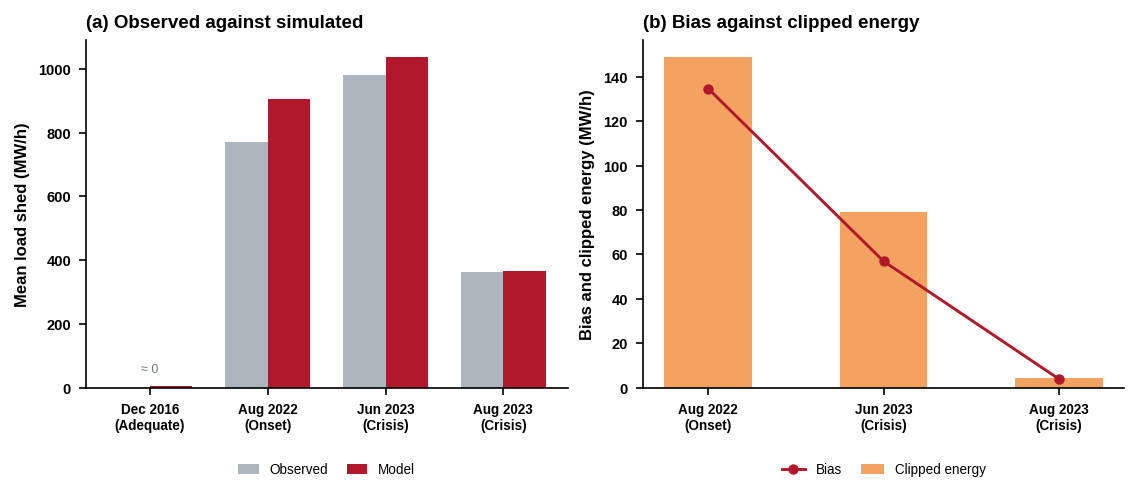

In [12]:
vd = val_df

per_lab_9 = {
    "2016-12": "Dec 2016\n(Adequate)",
    "2022-08": "Aug 2022\n(Onset)",
    "2023-06": "Jun 2023\n(Crisis)",
    "2023-08": "Aug 2023\n(Crisis)",
}

fig, axes = plt.subplots(1, 2, figsize=(7.48, 3.2), layout="constrained")

# ------------------------------------------------------------------
# (a) Observed against simulated
# ------------------------------------------------------------------
ax = axes[0]
x = np.arange(len(vd))

obs_bars = ax.bar(
    x - 0.18, vd["obs"], 0.36,
    color=Cpal["grey"], label="Observed",
)
mod_bars = ax.bar(
    x + 0.18, vd["model"], 0.36,
    color=Cpal["crisis"], label="Model",
)
if vd["obs"].iloc[0] < 5 and vd["model"].iloc[0] < 20:
    ax.annotate(
        "\u2248 0",
        xy=(0, 0), xytext=(0, 6),
        textcoords="offset points",
        ha="center", va="bottom",
        fontsize=6, color="#6C757D",
    )

ax.set_xticks(x)
ax.set_xticklabels(
    [per_lab_9[p] for p in vd["period"]],
    fontsize=6.5,
)
ax.set_ylabel("Mean load shed (MW/h)")
ax.set_title("(a) Observed against simulated", loc="left", fontweight="bold")
ax.legend(
    handles=[obs_bars, mod_bars],
    loc="upper center", bbox_to_anchor=(0.5, -0.20),
    ncol=2, frameon=False, columnspacing=1.4,
    handlelength=1.5, borderaxespad=0, fontsize=6.5,
)

# ------------------------------------------------------------------
# (b) Bias against clipped energy
# ------------------------------------------------------------------
ax = axes[1]
cri = vd[vd["state"] != "Adequate"]
x2 = np.arange(len(cri))

clip_bars = ax.bar(
    x2, cri["clipped_MW_per_h"], 0.5,
    color=Cpal["accent"], label="Clipped energy",
)
bias_line, = ax.plot(
    x2, cri["bias"], "o-",
    color=Cpal["crisis"], ms=4, lw=1.4, label="Bias",
)

ax.set_xticks(x2)
ax.set_xticklabels(
    [per_lab_9[p] for p in cri["period"]],
    fontsize=6.5,
)
ax.set_ylabel("Bias and clipped energy (MW/h)")
ax.set_title("(b) Bias against clipped energy", loc="left", fontweight="bold")
ax.legend(
    handles=[bias_line, clip_bars],
    loc="upper center", bbox_to_anchor=(0.5, -0.20),
    ncol=2, frameon=False, columnspacing=1.4,
    handlelength=1.7, borderaxespad=0, fontsize=6.5,
)

savefig(fig, "Figure09_reconstruction")
plt.show()

### Figure 10 — three model configurations

  Figure10_ablation: 4488x2129px = 7.48x3.55in  RGB


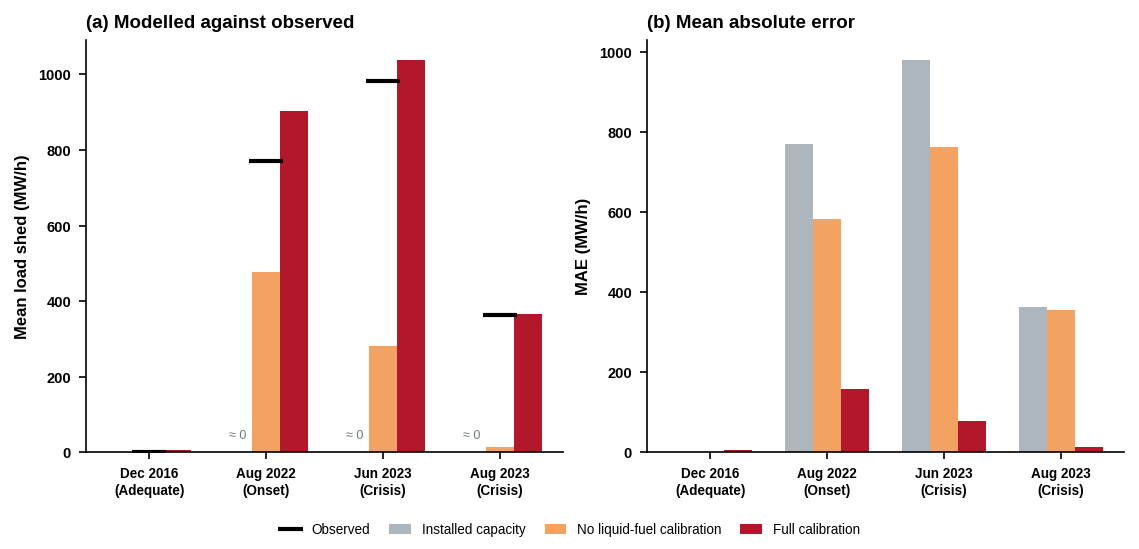

In [13]:
cfg_order = [
    "Model 1",
    "Model 2",
    "Model 3",
]

cfg_lab = {
    "Model 1": "Installed capacity",
    "Model 2": "No liquid-fuel calibration",
    "Model 3": "Full calibration",
}

cfg_col = {
    "Model 1": Cpal["grey"],
    "Model 2": Cpal["accent"],
    "Model 3": Cpal["crisis"],
}

per_lab = {
    "2016-12": "Dec 2016\n(Adequate)",
    "2022-08": "Aug 2022\n(Onset)",
    "2023-06": "Jun 2023\n(Crisis)",
    "2023-08": "Aug 2023\n(Crisis)",
}

def _v(period, configuration, field):
    result = abl_df[
        (abl_df["period"] == period)
        & (abl_df["config"] == configuration)
    ]

    return (
        float(result[field].iloc[0])
        if len(result)
        else np.nan
    )

fig, axes = plt.subplots(
    1,
    2,
    figsize=(7.48, 3.55),
    layout="constrained",
)

x = np.arange(len(PERIODS))
w = 0.24

# ------------------------------------------------------------------
# (a) Modelled against observed
# ------------------------------------------------------------------
ax = axes[0]

for j, cfg in enumerate(cfg_order):
    ax.bar(
        x + (j - 1) * w,
        [_v(period, cfg, "model") for period in PERIODS],
        w,
        color=cfg_col[cfg],
    )

ax.plot(
    x,
    [_v(period, "Model 3", "obs") for period in PERIODS],
    "k_", ms=16, mew=2,
)

# The installed-capacity bars round to zero in every crisis period, so
# without a marker the series reads as missing rather than as the result.
for k, period in enumerate(PERIODS):
    if _v(period, "Model 1", "model") < 5 and _v(period, "Model 3", "obs") > 50:
        ax.annotate(
            "\u2248 0",
            xy=(x[k] - w, 0),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center", va="bottom",
            fontsize=6, color="#6C757D",
        )

ax.set_xticks(x)
ax.set_xticklabels(
    [per_lab[period] for period in PERIODS],
    fontsize=6.5,
)
ax.set_ylabel("Mean load shed (MW/h)")
ax.set_title("(a) Modelled against observed", loc="left", fontweight="bold")

# ------------------------------------------------------------------
# (b) Mean absolute error
# ------------------------------------------------------------------
ax = axes[1]

for j, cfg in enumerate(cfg_order):
    ax.bar(
        x + (j - 1) * w,
        [_v(period, cfg, "mae") for period in PERIODS],
        w,
        color=cfg_col[cfg],
    )

ax.set_xticks(x)
ax.set_xticklabels(
    [per_lab[period] for period in PERIODS],
    fontsize=6.5,
)

ax.set_ylabel("MAE (MW/h)")

ax.set_title(
    "(b) Mean absolute error",
    loc="left",
    fontweight="bold",
)

# ------------------------------------------------------------------
# Shared legend below both panels
# ------------------------------------------------------------------
legend_handles = [
    plt.Line2D(
        [],
        [],
        color="black",
        marker="_",
        linestyle="none",
        markersize=12,
        markeredgewidth=2,
        label="Observed",
    ),
    mpatches.Patch(
        facecolor=cfg_col["Model 1"],
        label=cfg_lab["Model 1"],
    ),
    mpatches.Patch(
        facecolor=cfg_col["Model 2"],
        label=cfg_lab["Model 2"],
    ),
    mpatches.Patch(
        facecolor=cfg_col["Model 3"],
        label=cfg_lab["Model 3"],
    ),
]

fig.legend(
    handles=legend_handles,
    loc="outside lower center",
    ncol=4,
    frameon=False,
    fontsize=6.5,
    columnspacing=1.4,
    handlelength=1.6,
)

savefig(fig, "Figure10_ablation")
plt.show()

### Figure 11 — out-of-sample prediction

  Figure11_out_of_sample: 4488x1920px = 7.48x3.20in  RGB


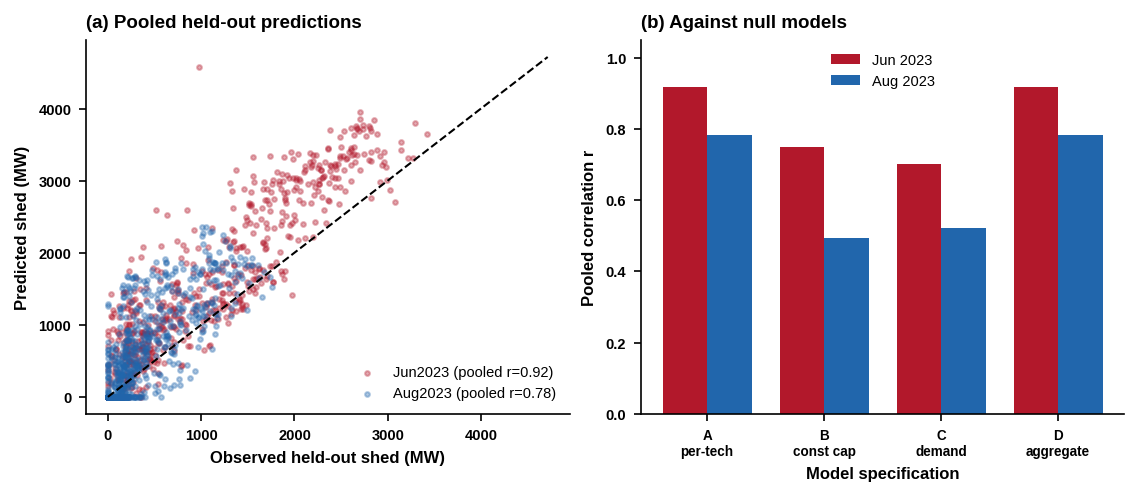

In [14]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(7.48, 3.2),
)

cols = {
    "Jun2023": Cpal["crisis"],
    "Aug2023": Cpal["normal"],
}

# ------------------------------------------------------------------
# (a) Held-out predictions
# ------------------------------------------------------------------
ax = axes[0]

for name, results in OOS_CAPTURE.items():
    ax.scatter(
        results["obs"],
        results["model"],
        s=5,
        alpha=0.35,
        color=cols[name],
        label=(
            f"{name} "
            f"(pooled r={results['pooled_r']:.2f})"
        ),
        rasterized=True,
    )

lim = max(
    max(
        results["obs"].max(),
        results["model"].max(),
    )
    for results in OOS_CAPTURE.values()
) * 1.03

ax.plot(
    [0, lim],
    [0, lim],
    "k--",
    lw=1,
)

ax.set_xlabel("Observed held-out shed (MW)")
ax.set_ylabel("Predicted shed (MW)")

ax.set_title(
    "(a) Pooled held-out predictions",
    loc="left",
    fontweight="bold",
)

ax.legend(frameon=False)

# ------------------------------------------------------------------
# (b) Comparison against null models
# ------------------------------------------------------------------
ax = axes[1]

labs = ["A", "B", "C", "D"]
xs = np.arange(len(labs))

for i, month in enumerate(["2023-06", "2023-08"]):
    values = [
        oos_null[
            (oos_null["month"] == month)
            & (oos_null["spec"] == NAMES[key])
        ]["r"].iloc[0]
        for key in labs
    ]

    ax.bar(
        xs + (i - 0.5) * 0.38,
        values,
        0.38,
        color=[
            Cpal["crisis"],
            Cpal["normal"],
        ][i],
        label=(
            "Jun 2023"
            if i == 0
            else "Aug 2023"
        ),
    )

ax.set_xticks(xs)
ax.set_xticklabels(
    [
        "A\nper-tech",
        "B\nconst cap",
        "C\ndemand",
        "D\naggregate",
    ],
    fontsize=6.5,
)

ax.set_xlabel("Model specification")
ax.set_ylabel("Pooled correlation r")
ax.set_ylim(0, 1.05)

ax.set_title(
    "(b) Against null models",
    loc="left",
    fontweight="bold",
)

ax.legend(frameon=False)

savefig(fig, "Figure11_out_of_sample")
plt.show()

### Figure 12 — global sensitivity analysis

Morris source: file
  Figure12_gsa: 4488x1920px = 7.48x3.20in  RGB


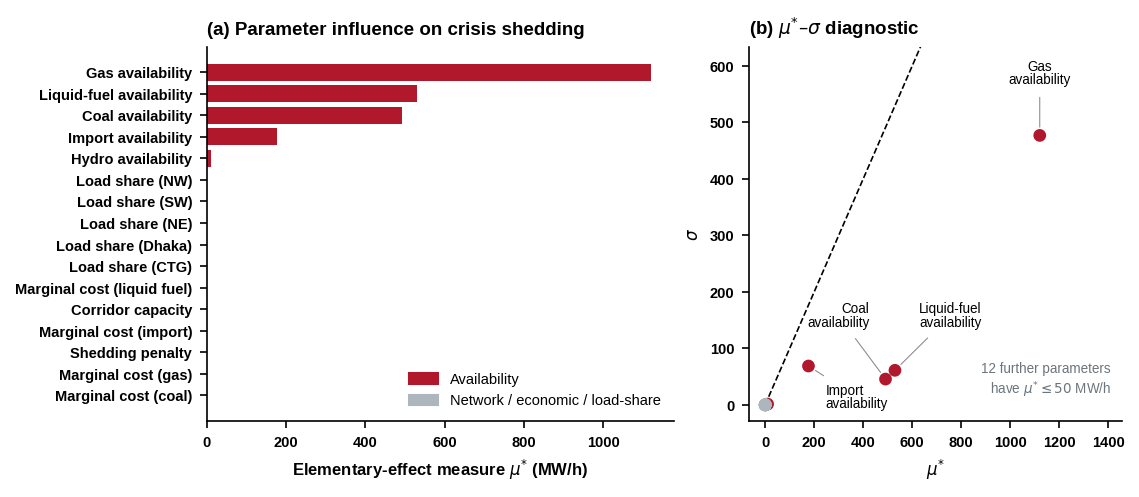

In [15]:
PUBLISHED = pd.DataFrame({
    "param": [
        "av_gas",
        "av_LF",
        "av_coal",
        "av_import",
        "av_hydro",
        "ls_NW",
        "ls_NE",
        "ls_Dhaka",
        "ls_SW",
        "ls_CTG",
        "corridor_cap",
        "mc_gas",
        "mc_coal",
        "mc_import",
        "mc_LF",
        "shed_penalty",
    ],
    "mu_star": [
        1120.9,
        529.8,
        491.2,
        176.7,
        9.7,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
    ],
    "sigma": [
        477.1,
        61.1,
        45.6,
        68.7,
        1.3,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
    ],
})

gsa = (
    pd.read_csv(MORRIS_CSV)
    if os.path.exists(MORRIS_CSV)
    else PUBLISHED
)

print(
    "Morris source:",
    "file" if os.path.exists(MORRIS_CSV)
    else "published values",
)

LAB = {
    "ls_NW": "Load share (NW)",
    "ls_NE": "Load share (NE)",
    "ls_Dhaka": "Load share (Dhaka)",
    "ls_SW": "Load share (SW)",
    "ls_CTG": "Load share (CTG)",
    "corridor_cap": "Corridor capacity",
    "mc_gas": "Marginal cost (gas)",
    "mc_coal": "Marginal cost (coal)",
    "mc_import": "Marginal cost (import)",
    "mc_LF": "Marginal cost (liquid fuel)",
    "shed_penalty": "Shedding penalty",
    "av_gas": "Gas availability",
    "av_coal": "Coal availability",
    "av_LF": "Liquid-fuel availability",
    "av_import": "Import availability",
    "av_hydro": "Hydro availability",
}

r10 = gsa.copy()
r10["is_av"] = r10["param"].str.startswith("av_")

fig, axes = plt.subplots(
    1,
    2,
    figsize=(7.48, 3.2),
    gridspec_kw={"width_ratios": [1.25, 1]},
    layout="constrained",
)

# ------------------------------------------------------------------
# (a) Parameter influence
# ------------------------------------------------------------------
ax = axes[0]

top = r10.sort_values("mu_star")

ax.barh(
    [LAB[param] for param in top["param"]],
    top["mu_star"],
    color=[
        Cpal["crisis"] if is_av else Cpal["grey"]
        for is_av in top["is_av"]
    ],
)

ax.set_xlabel(
    "Elementary-effect measure "
    r"$\mu^{*}$ (MW/h)"
)

ax.set_title(
    "(a) Parameter influence on crisis shedding",
    loc="left",
    fontweight="bold",
)

ax.legend(
    handles=[
        mpatches.Patch(
            color=Cpal["crisis"],
            label="Availability",
        ),
        mpatches.Patch(
            color=Cpal["grey"],
            label="Network / economic / load-share",
        ),
    ],
    frameon=False,
    loc="lower right",
)

# ------------------------------------------------------------------
# (b) Morris diagnostic
# ------------------------------------------------------------------
ax = axes[1]

ax.scatter(
    r10["mu_star"],
    r10["sigma"],
    color=[
        Cpal["crisis"] if is_av else Cpal["grey"]
        for is_av in r10["is_av"]
    ],
    s=26,
    zorder=3,
)

mx = max(r10["mu_star"].max(), 1)
sigma_max = max(r10["sigma"].max(), 1)

ax.plot(
    [0, mx],
    [0, mx],
    "k--",
    lw=0.8,
    zorder=1,
)

ax.set_xlim(
    -mx * 0.06,
    mx * 1.30,
)

ax.set_ylim(
    -sigma_max * 0.06,
    sigma_max * 1.33,
)

label_positions = {
    "av_gas": (
        mx,
        sigma_max * 1.18,
        "center",
        "bottom",
        "Gas\navailability",
    ),
    "av_coal": (
        mx * 0.38,
        sigma_max * 0.28,
        "right",
        "bottom",
        "Coal\navailability",
    ),
    "av_LF": (
        mx * 0.56,
        sigma_max * 0.28,
        "left",
        "bottom",
        "Liquid-fuel\navailability",
    ),
    "av_import": (
        mx * 0.22,
        sigma_max * 0.08,
        "left",
        "top",
        "Import\navailability",
    ),
}

labelled = r10[r10["mu_star"] > 50]

for _, row in labelled.iterrows():
    (
        text_x,
        text_y,
        horizontal_alignment,
        vertical_alignment,
        label,
    ) = label_positions.get(
        row["param"],
        (
            row["mu_star"],
            row["sigma"] + sigma_max * 0.10,
            "center",
            "bottom",
            LAB[row["param"]],
        ),
    )

    ax.annotate(
        label,
        xy=(row["mu_star"], row["sigma"]),
        xytext=(text_x, text_y),
        textcoords="data",
        ha=horizontal_alignment,
        va=vertical_alignment,
        fontsize=6.5,
        linespacing=0.95,
        arrowprops=dict(
            arrowstyle="-",
            lw=0.5,
            color="#888888",
            shrinkA=3,
            shrinkB=4,
        ),
        zorder=4,
    )

n_small = int((r10["mu_star"] <= 50).sum())

ax.text(
    0.97,
    0.06,
    f"{n_small} further parameters\n"
    r"have $\mu^{*} \leq 50$ MW/h",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=6.5,
    color="#6C757D",
)

ax.set_xlabel(r"$\mu^{*}$")
ax.set_ylabel(r"$\sigma$")

ax.set_title(
    r"(b) $\mu^{*}$–$\sigma$ diagnostic",
    loc="left",
    fontweight="bold",
)

savefig(fig, "Figure12_gsa")
plt.show()

### Figure 13 — intervention effectiveness across crisis months

  Figure13_effectiveness: 4488x1920px = 7.48x3.20in  RGB


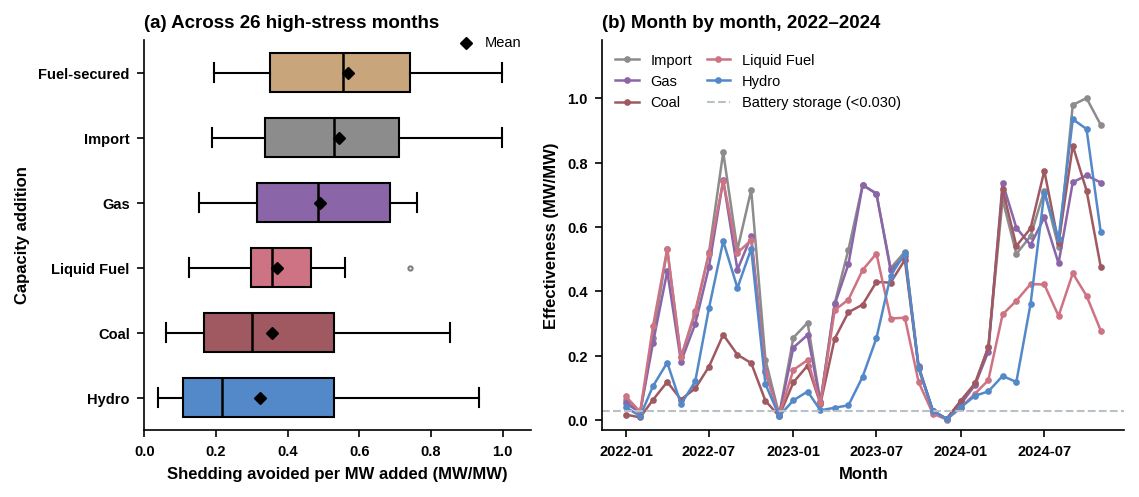

In [16]:
order = [
    "Hydro",
    "Coal",
    "Liquid Fuel",
    "Gas",
    "Import",
    "Fuel-secured",
]

series = {
    technology: hi[technology].values
    for technology in DISPATCHABLE
}

series["Fuel-secured"] = hi["secured"].values

OWID_EFFECT_COLORS = {
    "Hydro": "#5389C9",
    "Coal": "#A05961",
    "Liquid Fuel": "#CD7384",
    "Gas": "#8A65A7",
    "Import": "#8C8C8C",
    "Fuel-secured": "#C9A57B",
}

fig, axes = plt.subplots(
    1,
    2,
    figsize=(7.48, 3.2),
    gridspec_kw={"width_ratios": [1, 1.35]},
    layout="constrained",
)

# ------------------------------------------------------------------
# (a) Effectiveness across high-stress months
# ------------------------------------------------------------------
ax = axes[0]

bp = ax.boxplot(
    [series[technology] for technology in order],
    vert=False,
    widths=0.6,
    patch_artist=True,
    medianprops=dict(
        color="black",
        lw=1.2,
    ),
    flierprops=dict(
        marker="o",
        ms=2,
        alpha=0.5,
    ),
)

for patch, technology in zip(bp["boxes"], order):
    patch.set_facecolor(
        OWID_EFFECT_COLORS[technology]
    )

for i, technology in enumerate(order):
    ax.scatter(
        series[technology].mean(),
        i + 1,
        marker="D",
        s=14,
        color="black",
        zorder=5,
    )

ax.set_yticks(
    np.arange(1, len(order) + 1)
)

ax.set_yticklabels(order)
ax.set_xlim(0, 1.08)

ax.set_xlabel(
    "Shedding avoided per MW added (MW/MW)"
)

ax.set_ylabel("Capacity addition")

ax.set_title(
    f"(a) Across {N_HI} high-stress months",
    loc="left",
    fontweight="bold",
)

ax.scatter(
    [],
    [],
    marker="D",
    s=14,
    color="black",
    label="Mean",
)

ax.legend(
    frameon=False,
    loc="upper right",
    bbox_to_anchor=(1.0, 1.035),
    handletextpad=0.3,
    borderaxespad=0.25,
)

# ------------------------------------------------------------------
# (b) Monthly effectiveness
# ------------------------------------------------------------------
ax = axes[1]

xt = pd.to_datetime(
    interv["month"] + "-01"
)

for technology in [
    "Import",
    "Gas",
    "Coal",
    "Liquid Fuel",
    "Hydro",
]:
    ax.plot(
        xt,
        interv[technology],
        "-o",
        ms=2.2,
        lw=1.2,
        color=OWID_EFFECT_COLORS[technology],
        label=technology,
    )

ax.axhline(
    BATT_MAX_EFF,
    color="#B8C0C8",
    ls="--",
    lw=1.0,
    label=f"Battery storage (<{BATT_MAX_EFF:.3f})",
)

ax.set_ylim(-0.03, 1.18)

ax.set_xlabel("Month")
ax.set_ylabel("Effectiveness (MW/MW)")

# Show semiannual date labels to prevent overlap.
ax.xaxis.set_major_locator(
    mdates.MonthLocator(bymonth=[1, 7])
)
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y-%m")
)

ax.set_title(
    "(b) Month by month, 2022–2024",
    loc="left",
    fontweight="bold",
)

ax.legend(
    ncol=2,
    loc="upper left",
    frameon=True,
    framealpha=0.95,
    facecolor="white",
    edgecolor="none",
    handlelength=1.6,
    columnspacing=1.0,
)

savefig(fig, "Figure13_effectiveness")
plt.show()

### Figure 14 — capacity sweep

  Figure14_capacity_sweep: 4488x2010px = 7.48x3.35in  RGB


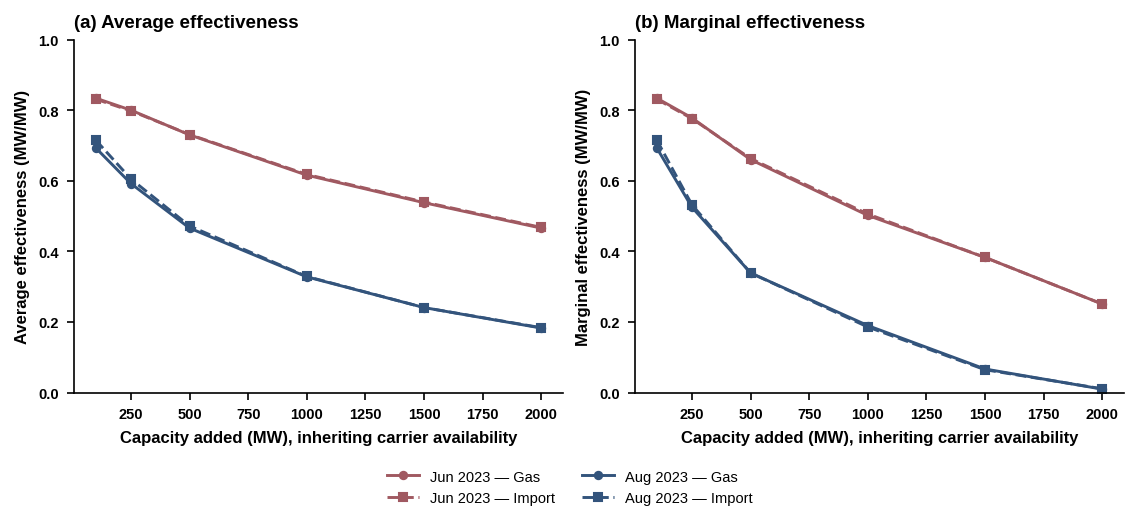

In [17]:
month_styles = {
    "2023-06": {
        "label": "Jun 2023",
        "color": "#A05961",
    },
    "2023-08": {
        "label": "Aug 2023",
        "color": "#33547C",
    },
}

technology_styles = {
    "Gas": {"linestyle": "-", "marker": "o"},
    "Import": {"linestyle": "--", "marker": "s"},
}

fig, axes = plt.subplots(
    1,
    2,
    figsize=(7.48, 3.35),
    layout="constrained",
)

legend_handles = []

# ------------------------------------------------------------------
# (a) Average effectiveness
# ------------------------------------------------------------------
ax = axes[0]

for (month, technology), data in sweep_df.groupby(["month", "tech"], sort=False):
    month_style = month_styles[month]
    technology_style = technology_styles[technology]

    line, = ax.plot(
        data["added_MW"],
        data["avg_eff"],
        color=month_style["color"],
        linestyle=technology_style["linestyle"],
        marker=technology_style["marker"],
        ms=3.5,
        lw=1.4,
        label=f"{month_style['label']} — {technology}",
    )
    legend_handles.append(line)

ax.set_xlabel("Capacity added (MW), inheriting carrier availability")
ax.set_ylabel("Average effectiveness (MW/MW)")
ax.set_ylim(0, 1)

ax.set_title(
    "(a) Average effectiveness",
    loc="left",
    fontweight="bold",
)

# ------------------------------------------------------------------
# (b) Marginal effectiveness
# ------------------------------------------------------------------
ax = axes[1]

for (month, technology), data in sweep_df.groupby(["month", "tech"], sort=False):
    month_style = month_styles[month]
    technology_style = technology_styles[technology]

    ax.plot(
        data["added_MW"],
        data["marg_eff"],
        color=month_style["color"],
        linestyle=technology_style["linestyle"],
        marker=technology_style["marker"],
        ms=3.5,
        lw=1.4,
    )

ax.set_xlabel("Capacity added (MW), inheriting carrier availability")
ax.set_ylabel("Marginal effectiveness (MW/MW)")
ax.set_ylim(0, 1)

ax.set_title(
    "(b) Marginal effectiveness",
    loc="left",
    fontweight="bold",
)

fig.legend(
    handles=legend_handles,
    loc="outside lower center",
    ncol=2,
    frameon=False,
    fontsize=7,
    columnspacing=1.8,
    handlelength=2.2,
)

savefig(fig, "Figure14_capacity_sweep")
plt.show()


## 4. Check and download

Confirms all twelve TIFF files are present, RGB, and at the intended print
width, then downloads a ZIP containing both TIFF and PDF versions.


In [18]:
import glob
print(f"  {'file':40s} {'px':>13s} {'inches':>13s} {'mode':>5s} {'OK':>4s}")
ok_all = True
expected = {f"Figure{number:02d}" for number in range(3, 15)}
found = set()

for f in sorted(glob.glob(f"{OUT_FIG}/*.tiff")):
    im = Image.open(f)
    w, h = im.size
    wi, hi = w / 600, h / 600
    ok = (im.mode == "RGB") and (3.2 <= wi <= 7.6)
    ok_all &= ok
    found.add(os.path.basename(f)[:8])
    print(
        f"  {os.path.basename(f):40s} {f'{w}x{h}':>13s} "
        f"{f'{wi:.2f}x{hi:.2f}':>13s} {im.mode:>5s} "
        f"{'yes' if ok else 'NO':>4s}"
    )

missing = sorted(expected - found)
ok_all &= not missing
if missing:
    print("\n  MISSING:", ", ".join(missing))
print("\n  " + ("ALL FIGURES MEET SUBMISSION REQUIREMENTS" if ok_all else "SOME FAIL"))

shutil.make_archive("/content/figures_v41", "zip", OUT_FIG)
files.download("/content/figures_v41.zip")


  file                                                px        inches  mode   OK
  Figure03_system_evolution.tiff               4488x4800     7.48x8.00   RGB  yes
  Figure04_capacity_robustness.tiff            4488x1800     7.48x3.00   RGB  yes
  Figure05_monthly_shedding.tiff               4488x1800     7.48x3.00   RGB  yes
  Figure06_idle_capacity.tiff                  4488x1860     7.48x3.10   RGB  yes
  Figure07_effect_sizes.tiff                   4488x2160     7.48x3.60   RGB  yes
  Figure08_seasonality.tiff                    4488x2129     7.48x3.55   RGB  yes
  Figure09_reconstruction.tiff                 4488x1920     7.48x3.20   RGB  yes
  Figure10_ablation.tiff                       4488x2129     7.48x3.55   RGB  yes
  Figure11_out_of_sample.tiff                  4488x1920     7.48x3.20   RGB  yes
  Figure12_gsa.tiff                            4488x1920     7.48x3.20   RGB  yes
  Figure13_effectiveness.tiff                  4488x1920     7.48x3.20   RGB  yes
  Figure14_capac

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>